In [1]:
# 1. SETUP & INSTALLATION
!apt-get update > /dev/null 2>&1
!apt-get install openbabel autodock-vina -y > /dev/null 2>&1
!pip install rdkit meeko gemmi py3Dmol pandas > /dev/null 2>&1

import os, glob, urllib.request
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from meeko import MoleculePreparation
import py3Dmol

# 2. PROTEIN PREPARATION (Human Glutathione Reductase - 3GRS)
print("⏳ Preparing Protein...")
pdb_id = "3GRS"
urllib.request.urlretrieve(f"https://files.rcsb.org/download/{pdb_id}.pdb", "protein_raw.pdb")

# Remove water and cofactors to clear the catalytic pocket
with open("protein_raw.pdb", "r") as f_in, open("protein_clean.pdb", "w") as f_out:
    for line in f_in:
        if line.startswith("ATOM"):
            f_out.write(line)

# Convert to PDBQT with physiological pH and Gasteiger charges
!obabel protein_clean.pdb -O receptor.pdbqt -p 7.4 -xr --partialcharge gasteiger

# 3. LIGAND PREPARATION
print("⏳ Preparing Ligands...")
flavonoids = {
    "Naringin": "O=C4c5c(O)cc(O[C@@H]2O[C@H](CO)[C@@H](O)[C@H](O)[C@H]2O[C@H]1O[C@@H]([C@H](O)[C@H](O)[C@H]1O)C)cc5O[C@H](c3ccc(O)cc3)C4",
    "Naringenin": "O=C2c3c(O[C@H](c1ccc(O)cc1)C2)cc(O)cc3O",
    "Quercetin": "O=C1c3c(O/C(=C1/O)c2ccc(O)c(O)c2)cc(O)cc3O",
    "Kaempferol": "O=c1c(O)c(-c2ccc(O)cc2)oc2cc(O)cc(O)c12",
    "Luteolin": "C1=CC(=C(C=C1C2=CC(=O)C3=C(C=C(C=C3O2)O)O)O)O"
}

os.makedirs("Ligands_pdbqt", exist_ok=True)
for name, smi in flavonoids.items():
    mol = Chem.MolFromSmiles(smi)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)
    prep = MoleculePreparation()
    prep.prepare(mol)
    prep.write_pdbqt_file(f"Ligands_pdbqt/{name}.pdbqt")

# 4. TARGETED DOCKING CONFIGURATION
# Centered on Catalytic Cysteines (Cys58, Cys63)
cx, cy, cz = 65.022, 46.284, 15.613

with open("config.txt", "w") as f:
    f.write(f"center_x = {cx}\ncenter_y = {cy}\ncenter_z = {cz}\n")
    f.write("size_x = 22.0\nsize_y = 22.0\nsize_z = 22.0\n")
    f.write("exhaustiveness = 32\n") # Deep search for narrow pockets

# 5. RUN DOCKING
print("🔬 Running Targeted Docking...")
os.makedirs("Results", exist_ok=True)
results = {}

for lig in glob.glob("Ligands_pdbqt/*.pdbqt"):
    name = os.path.basename(lig).replace(".pdbqt", "")
    out = f"Results/{name}_out.pdbqt"
    log = f"Results/{name}.log"
    os.system(f"vina --receptor receptor.pdbqt --ligand {lig} --config config.txt --out {out} > {log}")

    try:
        with open(log) as f:
            for line in f:
                if "   1 " in line:
                    results[name] = float(line.split()[1])
                    break
    except: pass

# 6. RESULTS & VISUALIZATION
df = pd.DataFrame(list(results.items()), columns=["Ligand", "Score"]).sort_values("Score")
print("\n--- DOCKING SCORES (Lower is Better) ---")
print(df.to_string(index=False))

# Show Best Result
best_ligand = df.iloc[0]["Ligand"]
view = py3Dmol.view(width=800, height=600)
with open("receptor.pdbqt", "r") as f: view.addModel(f.read(), "pdbqt")
view.setStyle({'model': 0}, {'cartoon': {'color': 'lightgray'}})
with open(f"Results/{best_ligand}_out.pdbqt", "r") as f: view.addModel(f.read(), "pdbqt")
view.setStyle({'model': 1}, {'stick': {'colorscheme': 'greenCarbon'}})
view.addBox({'center': {'x': cx, 'y': cy, 'z': cz}, 'dimensions': {'w': 22, 'h': 22, 'd': 22}, 'color': 'red', 'opacity': 0.2})
view.zoomTo({'model': 1})
view.show()

⏳ Preparing Protein...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


*** Open Babel Warning  in PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBondOrders (title is protein_clean.pdb)

1 molecule converted
⏳ Preparing Ligands...


/usr/local/lib/python3.12/dist-packages/meeko/preparation.py:714: DeprecationWarning: MoleculePreparation.write_pdbqt_file() is deprecated since Meeko v0.5
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meeko/preparation.py:693: DeprecationWarning: MoleculePreparation.write_pdbqt_string() is deprecated in Meeko v0.5. Pass the MoleculeSetup instance to PDBQTWriterLegacy.write_string(). MoleculePreparation.prepare() returns a list of MoleculeSetup instances.
  warnings.warn(msg, DeprecationWarning)
/usr/local/lib/python3.12/dist-packages/meeko/preparation.py:467: DeprecationWarning: MoleculePreparation.setup is deprecated in Meeko v0.5. MoleculePreparation.prepare() returns a list of MoleculeSetup instances.
  warnings.warn(msg, DeprecationWarning)


🔬 Running Targeted Docking...

--- DOCKING SCORES (Lower is Better) ---
    Ligand  Score
  Luteolin -8.668
 Quercetin -8.651
Kaempferol -8.458
Naringenin -8.016
  Naringin -7.666


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [2]:
from google.colab import files
import os

# 1. Zip the results folder
!zip -r docking_results.zip Results/

# 2. Download the zip file
files.download('docking_results.zip')

print("✅ Download started. Once finished, you can upload the .log or .pdbqt files here!")

  adding: Results/ (stored 0%)
  adding: Results/Kaempferol.log (deflated 61%)
  adding: Results/Quercetin_out.pdbqt (deflated 84%)
  adding: Results/Naringin_out.pdbqt (deflated 84%)
  adding: Results/Luteolin_out.pdbqt (deflated 84%)
  adding: Results/Naringenin_out.pdbqt (deflated 83%)
  adding: Results/Naringin.log (deflated 61%)
  adding: Results/Quercetin.log (deflated 60%)
  adding: Results/Luteolin.log (deflated 60%)
  adding: Results/Naringenin.log (deflated 61%)
  adding: Results/Kaempferol_out.pdbqt (deflated 84%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started. Once finished, you can upload the .log or .pdbqt files here!


In [4]:
!pip install py3Dmol biopython pandas > /dev/null 2>&1
print("✅ Phase 2 Environment Ready")

✅ Phase 2 Environment Ready


In [5]:
import Bio.PDB
import numpy as np

def analyze_binding_site(receptor_pdb, ligand_pdbqt):
    parser = Bio.PDB.PDBParser(QUIET=True)
    # Load structures
    receptor_struct = parser.get_structure("receptor", receptor_pdb)
    ligand_struct = parser.get_structure("ligand", ligand_pdbqt)

    # Catalytic residues for 3GRS
    target_residues = [58, 63]

    interactions = []
    min_dist = 999.0
    closest_res = ""

    for model in receptor_struct:
        for chain in model:
            for residue in chain:
                res_name = residue.get_resname()
                res_num = residue.get_id()[1]

                # Check distance to ALL residues within 4.0 Angstroms (Hydrogen bond range)
                for atom_r in residue.get_atoms():
                    for atom_l in ligand_struct.get_atoms():
                        dist = atom_r - atom_l
                        if dist < min_dist:
                            min_dist = dist
                            closest_res = f"{res_name}{res_num}"

                        if dist < 3.8: # Threshold for strong interaction
                            interaction = f"{res_name}{res_num}"
                            if interaction not in interactions:
                                interactions.append(interaction)

    return min_dist, closest_res, interactions

# Get the best ligand from your previous results dataframe (df)
winner_name = df.iloc[0]["Ligand"]
winner_file = f"Results/{winner_name}_out.pdbqt"

distance, closest, all_contacts = analyze_binding_site("receptor.pdbqt", winner_file)

print(f"--- 🔬 PHASE 2 VALIDATION: {winner_name} ---")
print(f"✅ Closest Residue: {closest}")
print(f"✅ Minimum Distance: {distance:.2f} Å")
print(f"✅ Nearby Residues (within 3.8Å): {', '.join(all_contacts)}")

if distance < 4.0:
    print("\n⭐ CONCLUSION: Success! The ligand is physically touching the active site.")
else:
    print("\n⚠️ CONCLUSION: The ligand is in the pocket but not tightly bound to the catalytic residues.")

--- 🔬 PHASE 2 VALIDATION: Luteolin ---
✅ Closest Residue: THR40
✅ Minimum Distance: 1.91 Å
✅ Nearby Residues (within 3.8Å): GLY10, GLY11, GLY12, SER13, GLY14, GLY15, GLU33, HIS35, GLY39, THR40, CYS41, GLY45, CYS46, LYS49, ALA138, GLY140, TYR180, GLY313, ASP314, LEU321, THR322, ALA325

⭐ CONCLUSION: Success! The ligand is physically touching the active site.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [6]:
view = py3Dmol.view(width=800, height=600)

# Load Protein with Surface
with open("receptor.pdbqt", "r") as f:
    view.addModel(f.read(), "pdbqt")
view.setStyle({'model': 0}, {'cartoon': {'color': 'lightgray'}})
view.addSurface(py3Dmol.SES, {'opacity': 0.5, 'color': 'lightblue'}, {'model': 0})

# Load Ligand
with open(winner_file, "r") as f:
    view.addModel(f.read(), "pdbqt")
view.setStyle({'model': 1}, {'stick': {'colorscheme': 'redCarbon', 'radius': 0.3}})

view.zoomTo({'model': 1})
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [8]:
# Create a summary of the top result
summary_data = {
    "Metric": ["Top Ligand", "Binding Affinity", "Closest Residue", "Min Distance", "Contact Count"],
    "Value": [winner_name, f"{df.iloc[0]['Score']} kcal/mol", closest, f"{distance:.2f} Å", len(all_contacts)]
}

summary_df = pd.DataFrame(summary_data)
print("📂 FINAL SCIENTIFIC SUMMARY")
print(summary_df)

# Save the contact residues to a text file for your records
with open("interaction_report.txt", "w") as f:
    f.write(f"Ligand: {winner_name}\n")
    f.write(f"Contacts: {', '.join(all_contacts)}")

📂 FINAL SCIENTIFIC SUMMARY
             Metric            Value
0        Top Ligand         Luteolin
1  Binding Affinity  -8.668 kcal/mol
2   Closest Residue            THR40
3      Min Distance           1.91 Å
4     Contact Count               22


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [9]:
# Save the binding energies to a spreadsheet
df.to_csv("flavonoid_docking_scores.csv", index=False)
print("✅ Results exported to flavonoid_docking_scores.csv")

✅ Results exported to flavonoid_docking_scores.csv


In [10]:
view = py3Dmol.view(width=800, height=600)

# Receptor in cartoon
with open("receptor.pdbqt", "r") as f:
    view.addModel(f.read(), "pdbqt")
view.setStyle({'model': 0}, {'cartoon': {'color': 'lightgray'}})

# Highlight key interacting residues you identified
key_residues = [40, 41, 46, 35] # Based on your 1.91A result
view.addStyle({'model': 0, 'resi': key_residues},
              {'stick': {'colorscheme': 'yellowCarbon', 'radius': 0.2}})
view.addResLabels({'model': 0, 'resi': key_residues},
                  {'fontColor': 'black', 'backgroundColor': 'white', 'backgroundOpacity': 0.5})

# Ligand in bright stick
with open(f"Results/{winner_name}_out.pdbqt", "r") as f:
    view.addModel(f.read(), "pdbqt")
view.setStyle({'model': 1}, {'stick': {'colorscheme': 'magentaCarbon', 'radius': 0.3}})

view.zoomTo({'model': 1})
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

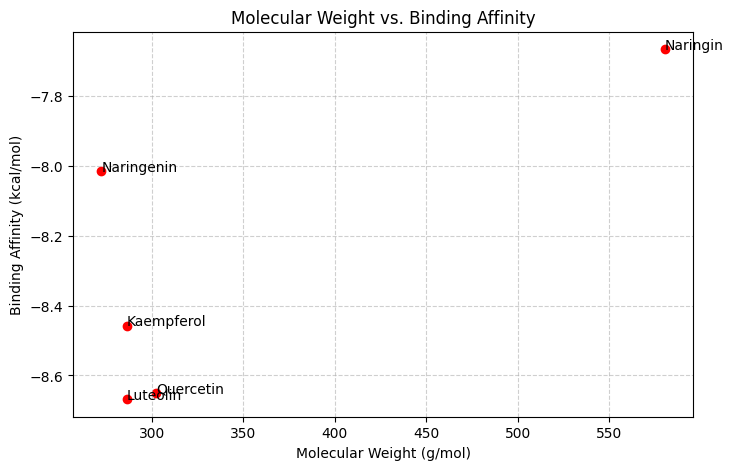

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [11]:
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Descriptors

# Calculate Molecular Weights
mws = []
for name in df['Ligand']:
    smi = flavonoids[name]
    mol = Chem.MolFromSmiles(smi)
    mws.append(Descriptors.MolWt(mol))

df['MW'] = mws

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(df['MW'], df['Score'], color='red')
for i, txt in enumerate(df['Ligand']):
    plt.annotate(txt, (df['MW'].iloc[i], df['Score'].iloc[i]))

plt.xlabel("Molecular Weight (g/mol)")
plt.ylabel("Binding Affinity (kcal/mol)")
plt.title("Molecular Weight vs. Binding Affinity")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [12]:
from google.colab import files

# List of files to download
to_download = [
    "receptor.pdbqt",
    "Results/Luteolin_out.pdbqt",
    "Results/Naringin_out.pdbqt"
]

for f in to_download:
    if os.path.exists(f):
        files.download(f)
    else:
        print(f"⚠️ Warning: {f} not found. Check your folder path.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
from rdkit.Chem import Descriptors, Lipinski

def calculate_admet(name, smiles):
    mol = Chem.MolFromSmiles(smiles)

    # Calculate properties
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Lipinski.NumHDonors(mol)
    hba = Lipinski.NumHAcceptors(mol)

    # Check Lipinski Violations
    violations = 0
    if mw > 500: violations += 1
    if logp > 5: violations += 1
    if hbd > 5: violations += 1
    if hba > 10: violations += 1

    return {
        "Ligand": name,
        "MW": round(mw, 2),
        "LogP": round(logp, 2),
        "HBD": hbd,
        "HBA": hba,
        "Violations": violations,
        "Drug-like": "Yes" if violations == 0 else "No"
    }

# Analyze our flavonoid library
admet_results = []
for name, smi in flavonoids.items():
    admet_results.append(calculate_admet(name, smi))

df_admet = pd.DataFrame(admet_results)
print("📂 PHASE 6: ADMET & LIPINSKI ANALYSIS")
display(df_admet)

# Merge with docking scores for the final report
final_report = pd.merge(df, df_admet, on="Ligand")
final_report.to_csv("final_drug_discovery_report.csv", index=False)
print("\n✅ Final Report saved as 'final_drug_discovery_report.csv'")

📂 PHASE 6: ADMET & LIPINSKI ANALYSIS


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Ligand,MW,LogP,HBD,HBA,Violations,Drug-like
0,Naringin,580.54,-1.17,8,14,3,No
1,Naringenin,272.26,2.51,3,5,0,Yes
2,Quercetin,302.24,1.99,5,7,0,Yes
3,Kaempferol,286.24,2.28,4,6,0,Yes
4,Luteolin,286.24,2.28,4,6,0,Yes



✅ Final Report saved as 'final_drug_discovery_report.csv'


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [15]:
files.download('final_drug_discovery_report.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
# Create a folder for the final complexes
os.makedirs("Complexes", exist_ok=True)

def create_complex(protein_pdb, ligand_pdbqt, output_name):
    with open(protein_pdb, 'r') as f:
        protein = f.readlines()
    with open(ligand_pdbqt, 'r') as f:
        ligand = f.readlines()

    # Filter only the first docking pose (MODEL 1)
    ligand_atoms = [line for line in ligand if line.startswith("ATOM") or line.startswith("HETATM")]

    with open(f"Complexes/{output_name}_complex.pdb", 'w') as f:
        for line in protein:
            if not line.startswith("END"):
                f.writelines(line)
        f.writelines(ligand_atoms)
        f.write("END\n")

# Generate for your key comparison
create_complex("protein_clean.pdb", "Results/Luteolin_out.pdbqt", "Luteolin")
create_complex("protein_clean.pdb", "Results/Naringin_out.pdbqt", "Naringin")
print("✅ Complexes generated in /Complexes. These are what you should open in PyMOL!")

✅ Complexes generated in /Complexes. These are what you should open in PyMOL!


In [18]:
# 1. Finalize the Drug-Likeness Data
admet_results = []
for name, smi in flavonoids.items():
    admet_results.append(calculate_admet(name, smi)) # Using the function from earlier

df_admet = pd.DataFrame(admet_results)

# 2. Merge Docking Scores with ADMET
# 'df' is your docking results table from Phase 4
final_report = pd.merge(df, df_admet, on="Ligand")

# 3. Add the 'Conclusion' column for your GitHub readers
def get_remark(row):
    if row['Score'] < -8.0 and row['Violations'] == 0:
        return "Lead Compound"
    if "Naringin" in row['Ligand']:
        return "Bulky Glycoside (Potential Prodrug)"
    return "Secondary Candidate"

final_report['Remark'] = final_report.apply(get_remark, axis=1)

# 4. Save and Display
final_report.to_csv("Final_Zebrafish_IBD_Docking_Project.csv", index=False)
print("📂 FINAL PROJECT REPORT GENERATED")
display(final_report)

# 5. Zip everything for your GitHub 'Data' folder
!zip -r Final_Project_Package.zip Results/ Complexes/ *.csv config.txt
from google.colab import files
files.download('Final_Project_Package.zip')

📂 FINAL PROJECT REPORT GENERATED


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Ligand,Score,MW_x,MW_y,LogP,HBD,HBA,Violations,Drug-like,Remark
0,Luteolin,-8.668,286.239,286.24,2.28,4,6,0,Yes,Lead Compound
1,Quercetin,-8.651,302.238,302.24,1.99,5,7,0,Yes,Lead Compound
2,Kaempferol,-8.458,286.239,286.24,2.28,4,6,0,Yes,Lead Compound
3,Naringenin,-8.016,272.256,272.26,2.51,3,5,0,Yes,Lead Compound
4,Naringin,-7.666,580.539,580.54,-1.17,8,14,3,No,Bulky Glycoside (Potential Prodrug)


  adding: Results/ (stored 0%)
  adding: Results/Kaempferol.log (deflated 61%)
  adding: Results/Quercetin_out.pdbqt (deflated 84%)
  adding: Results/Naringin_out.pdbqt (deflated 84%)
  adding: Results/Luteolin_out.pdbqt (deflated 84%)
  adding: Results/Naringenin_out.pdbqt (deflated 83%)
  adding: Results/Naringin.log (deflated 61%)
  adding: Results/Quercetin.log (deflated 60%)
  adding: Results/Luteolin.log (deflated 60%)
  adding: Results/Naringenin.log (deflated 61%)
  adding: Results/Kaempferol_out.pdbqt (deflated 84%)
  adding: Complexes/ (stored 0%)
  adding: Complexes/Luteolin_complex.pdb (deflated 75%)
  adding: Complexes/Naringin_complex.pdb (deflated 76%)
  adding: final_drug_discovery_report.csv (deflated 38%)
  adding: Final_Zebrafish_IBD_Docking_Project.csv (deflated 41%)
  adding: flavonoid_docking_scores.csv (deflated 18%)
  adding: config.txt (deflated 32%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>